# House Pricing Estimator - An End-To-End Machine Learning Pipeline

## 1- Problem

- A startup real estate company in California wants to assign accurate pricing estimates that suite both house owners and buyers. The goal is to help sellers list correctly and offer good prices for buyers.

- Tackling this problem would satisfy both house owners and buyers. This will increase the companys' reputation and attract more house owners to list their houses and more buyers to purchase those houses, resulting in good offers for both sides and satisfying stakeholders.

- To address this problem, we should think about it as a Supervised learning regression problem that a prediction model can solve by learning from previous recorded data with batch learning and makes assumptions about housing prices using parametric algorithms. doing so would require the following steps:
    1. Data Collection: First, we need to find a relevant dataset that includes information about house features in California and the price of each one.
    2. Data Exploration: To get a better understanding of the dataset, we need to visualize some plots to explore the data.
    3. Data Preprocessing: Information found in the data exploration stage would then be used to perform some data cleaning, sampling, and transformation.
    4. Feature Engineering: In this step, all object data is converted into a numerical format with encoding and numerical data will be scaled. This is done to make the data fit our models.
  5. Training Model: An appropriate machine learning model will be chosen for training, and model hyperparameters will be tuned to get the best model output score before finally training the model.
  6. Model Assessment: Prediction examples will be presented, and Relevant metrics for the selected model will be used to evaluate its performance and decide if it can be deployed to solve the business problem.

## 2- Data Collection

Importing all the required modules.

In [1]:
import pandas
from sklearn.model_selection import train_test_split

import seaborn
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from scipy.stats import loguniform
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

For this pipeline, the [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices) dataset on Kaggle will be used to solve the problem.

Importing models used in data collection.

We Assign the data into a "dataset" variable.

In [2]:
dataset = pandas.read_csv("housing.csv")

This dataset ok Kaggle doesn't come with a testing dataset, so we Immediately split the data into training and testing data to avoid data leakage:
* 80% of the data will be assigned to a "train_dataset variable"
* the remaining 20% of the data will be assigned to "test_dataset"
* A "random_state" value is assigned to make sure the data always splits into the same training and testing datasets.


In [3]:
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=25)

## 3- Data exploration

A glimpse on the tables' schema with 5 rows to have a general overview on the data.

In [4]:
train_dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14105,-117.10,32.75,15.0,2422.0,774.0,2120.0,715.0,1.0617,92400.0,NEAR OCEAN
20250,-119.18,34.24,17.0,629.0,221.0,514.0,186.0,3.2847,112500.0,NEAR OCEAN
5191,-118.26,33.93,36.0,1102.0,247.0,702.0,225.0,1.5256,95400.0,<1H OCEAN
664,-122.14,37.70,36.0,1266.0,228.0,606.0,239.0,3.9702,194100.0,NEAR BAY
8557,-118.40,33.93,35.0,2217.0,447.0,1000.0,450.0,4.7319,376100.0,<1H OCEAN


The data shows the properties and prices of houses in different geographical coordinates.

Printing some information about the dataset to familiarize ourselves with the dataset

In [5]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 14105 to 6618
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16351 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB


There is a total of 16512 rows and 10 rows (9 float64 and 1 object data type). Total_bedrooms attribute has 161 null values. Since 161 is not a big number, we can just remove all these rows from the dataset.

We plot A histogram to show the frequency of each attributes' values.

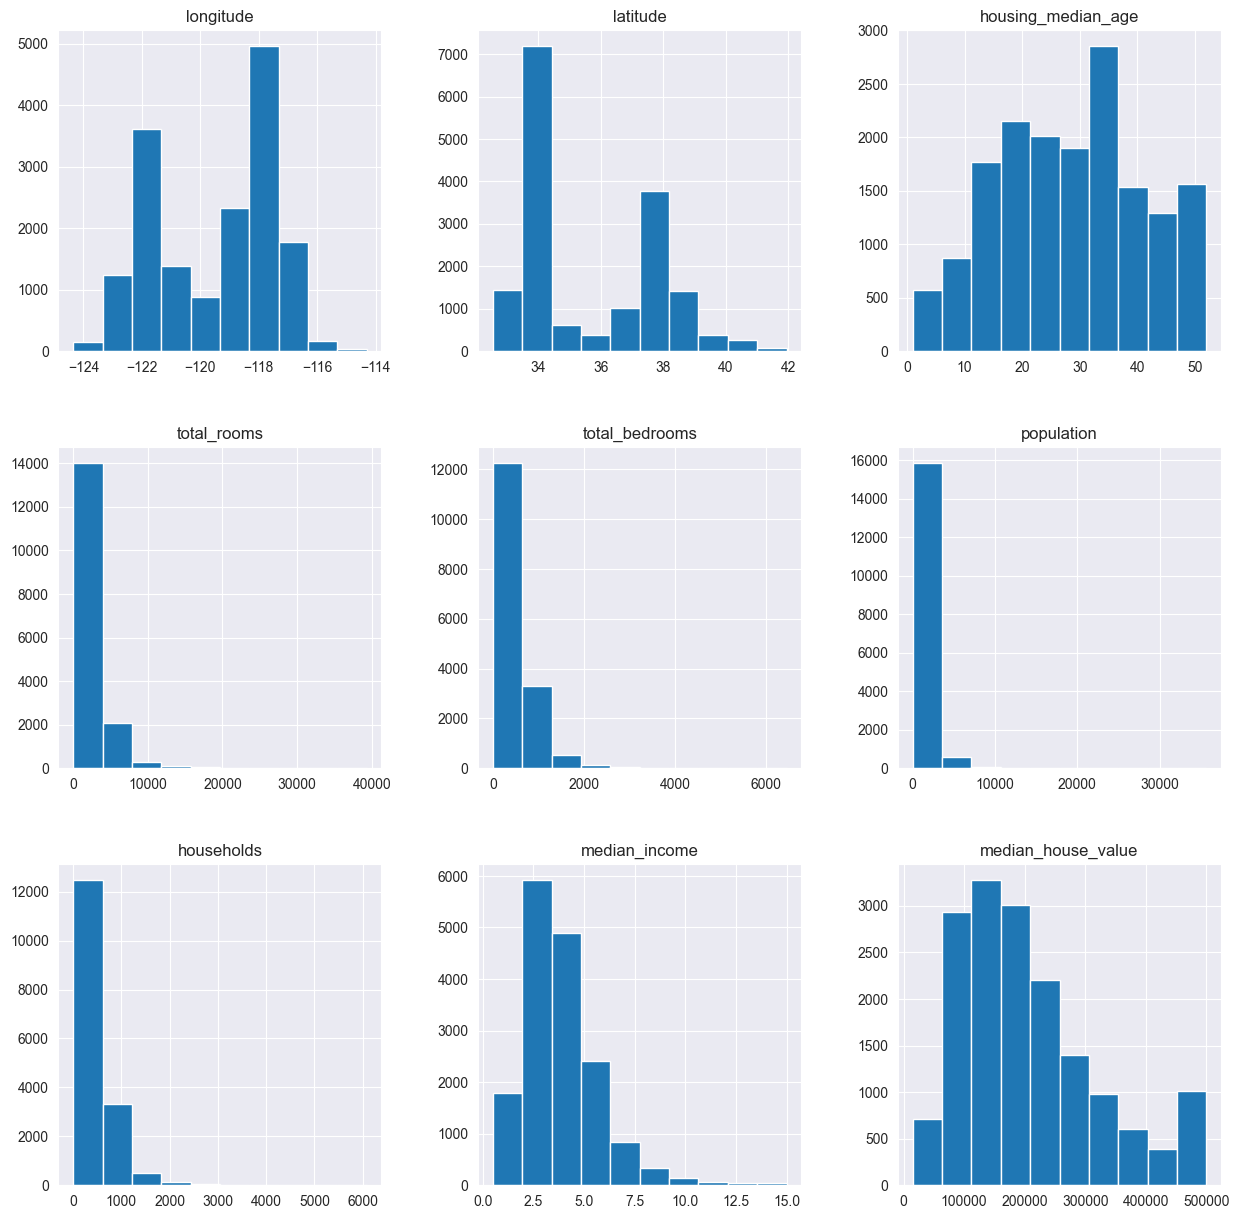

In [6]:
train_dataset.hist(figsize=(15,15));

It is clear that some attributes (total_rooms, total_bedrooms, population, households, and median_income) are right skewed. This means that we have to transform those attributes to reduce the effect of outliers and make it easier for the machine learning model to work with these attributes' values.

Plotting a correlation plot would help in locating attributes that highly correlates with our target value.

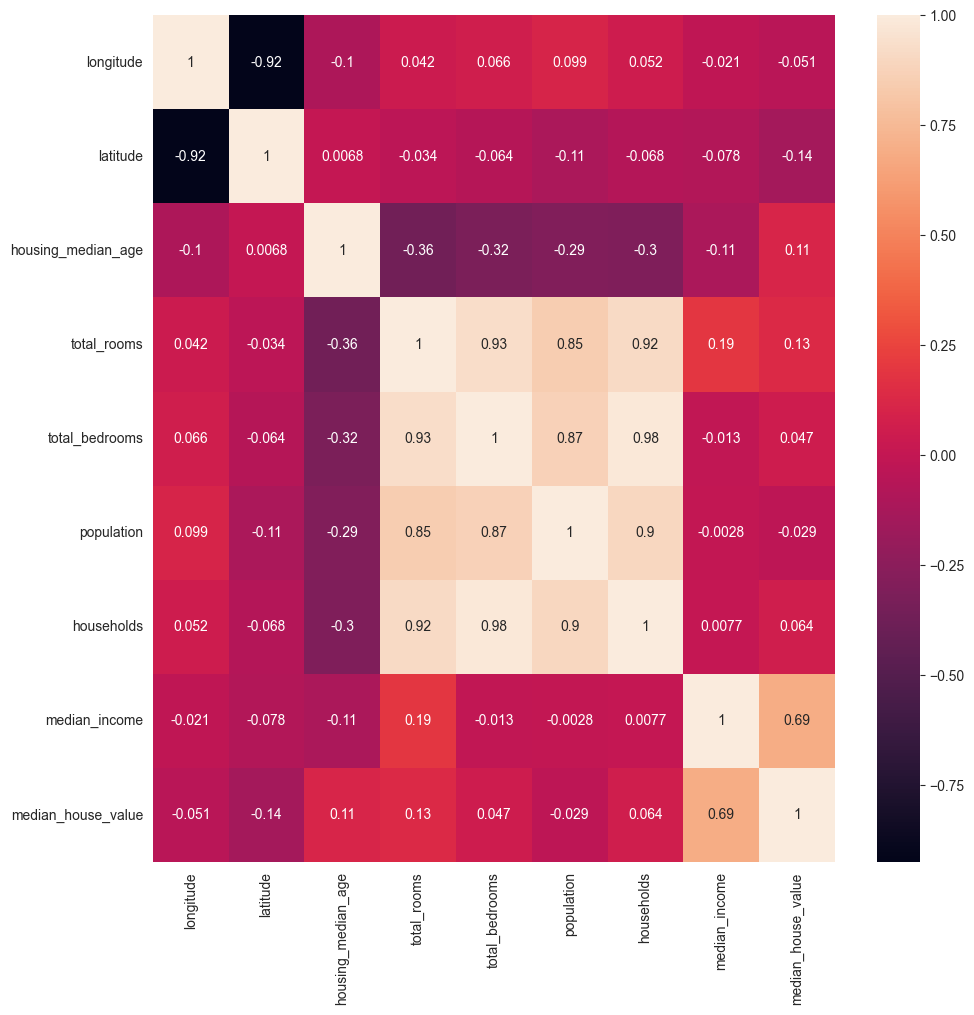

In [7]:
plt.figure(figsize=(11,11))
seaborn.heatmap(train_dataset.select_dtypes(include=["float64"]).corr(), annot=True);

The correlation matrix plot above shows that there is a high correlation between total_rooms, total_bedrooms, population, and households; Moreover, there is a high correlation between median house value (our target value) and median_income. This information will later be important for feature engineering

Plotting a regression plot between "median_income" and our target value (median_house_value) because "median_income" is the only property that highly correlated with the target value.

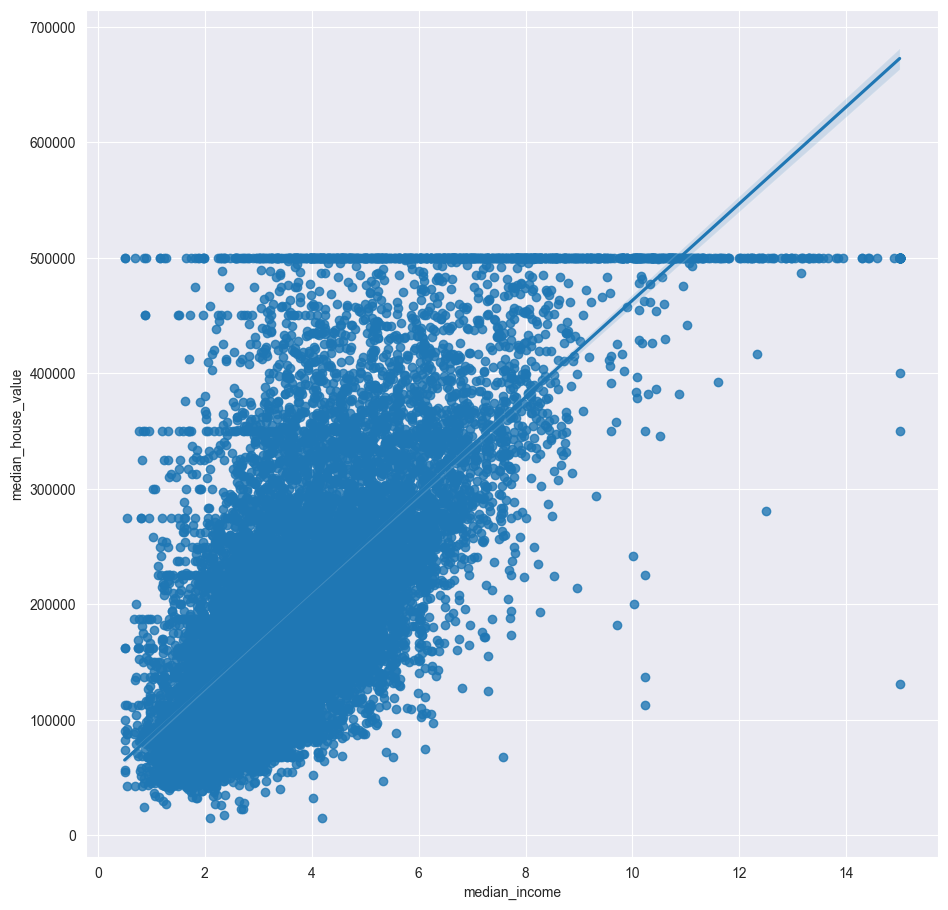

In [8]:
plt.figure(figsize=(11,11))
seaborn.regplot(data=train_dataset, x="median_income", y="median_house_value");

From the regression plot above, it appears that most of the data points have a linear relationship, but there are still some outliers, especially when the "median_income" goes above 60,000$. This could cause some major inaccuracies when the model tries to predict the price of an expensive house.

Scatter plot between "latitude" and "longitude".

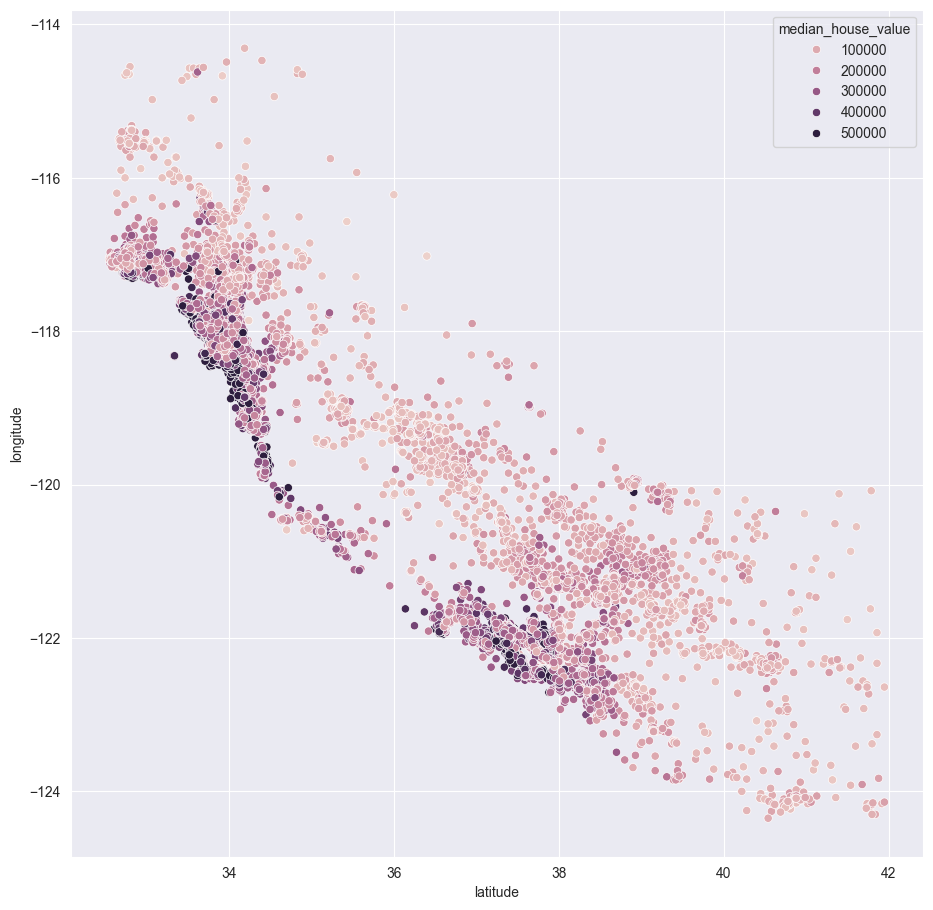

In [9]:
plt.figure(figsize=(11,11))
seaborn.scatterplot(data=train_dataset, x="latitude", y="longitude", hue="median_house_value");

The scatter plot below shows how the data is scattered in each coordinate according to our target value. These scatterd dots look like california on the map. We can see that houses near the ocean tend to be more expensive than those that are furthure away from the ocean.

## 4- Preprocessing

Removing null values from the tables.

In [10]:
train_dataset = train_dataset.dropna()
test_dataset = test_dataset.dropna()

Transforming attributes that had a left skewed histograms using logarithmic transformation.

In [11]:
def data_transformation(table):
    table['total_rooms'] = np.log(table['total_rooms'] + 1)
    table['total_bedrooms'] = np.log(table['total_bedrooms'] + 1)
    table['population'] = np.log(table['population'] + 1)
    table['households'] = np.log(table['households'] + 1)
    table['median_income'] = np.log(table['median_income'] + 1)

In [12]:
data_transformation(train_dataset)
data_transformation(test_dataset)

## 5- Feature Engineering

Assigning each of the feature and target values for both training and testing datasets into a separate variable so that they can be used in the model.

In [13]:
train_dataset_features = train_dataset.drop(["median_house_value"], axis=1)
train_dataset_targets = train_dataset["median_house_value"]

test_dataset_features = test_dataset.drop(["median_house_value"], axis=1)
test_dataset_targets = test_dataset["median_house_value"]

Before training the model, our data have two issues:
- Not all attributes are numerical.
- Numerical columns are not scaled, this means that attributes with higher values would take over on the learning process

To fix these issues we first have to identify the column names of numerical and categorieal attributes and then store each one of them in a separate variable.

In [14]:
categorial_attributes = train_dataset_features.select_dtypes(include=["object"]).columns
numerical_attributes = train_dataset_features.select_dtypes(include=["float64"]).columns

Then we need to use "Column transformer" along with:
1. OneHotEncoder: To encode object data into binary data
2. StandardScaler: To Scale numerical data

In [15]:
column_transformer = ColumnTransformer([
    ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore"), categorial_attributes),
    ("standard_scaler", StandardScaler(), numerical_attributes),
], remainder="passthrough")

Now that the data is ready, we can proceed with applying the transformations we made in the previous cell, and only fit the training data into the column transformer. We don't fit the testing data because we don't want to use it in the learning process as this will cause data leakage.

In [16]:
train_dataset_features = column_transformer.fit_transform(train_dataset_features)
test_dataset_features = column_transformer.transform(test_dataset_features)

## 6- Training Models

Now we can proceed with training and comparing several machine learning models like:
1. Linear Regressor: This is the simplest model for regression problems, it works by trying to minimize the mean squared error, which is the mean of the sum of all differences between predicted and actual values squared.
2. Ridge Regressor: It is similar to the Linear regression model, but it adds a regularizing parameter to penalize the linear regression equation when it have large coefficients to make it less complex; Therefore, preventing the model from overfitting.  When the parameter is low, the penalty is low and there is little to no effect. But when the parameter is high, the model tries to decrease the value of the coefficients as much as possible (but never to zero).
3. K Nearest Neighbors (KNN) Regressor: KNN makes predictions by looking at datapoints in the table with similar values to our target value and calculating the average of all their target values.
4. Random Forest Regression: This model creates a bunch of decision trees that are randomly assigned to train on a set of attributes and values. Then it makes a prediction by calculating the mean of all the prediction results of those decision trees.
5. SRV Regressor: SRV tries to draw two regression lines that act as a tube that tries to have as many data points inside it as possible, but also it tries to have as much of those outside close to it as possible. It makes a prediction based on the points outsite and on the tube, ignoring the points inside the tube.


In [17]:
linear_regressor = LinearRegression()
ridge_linear_regressor = Ridge()
knn_regressor = KNeighborsRegressor()
random_forest_regressor = RandomForestRegressor(random_state=25)
svr_regressor = SVR()

Before training models, we need to perform Hyperparameter tuning. This is done by choosing the most important hyperparameters for each model and giving it a set of values that it can use (Looking at the documentation of each model will help in choosing the best hyperparameters and values). Then we use an algorithm like RandomSearch or GridSearch to find the best value for each hyperparameter.

In [18]:
ridge_linear_regressor_parameters = {
    "alpha": loguniform(0.001, 100)
}
knn_regressor_parameters_grid = {
    "n_neighbors" : randint(3, 16),
    "weights" : ["distance", "uniform"]
}
random_forest_regressor_parameters_grid = {
    "n_estimators" : randint(50, 300),
    "max_depth" : randint(5, 30)
}
svr_regressor_parameters_grid = {
    "kernel" : ["linear", "poly", "rbf", "sigmoid"],
    "degree" : [2, 3, 4],
    "gamma" : ["scale", "auto", 0.001, 0.01, 0.1]
}

Now we choose to use RandomSearch for finding the best hyperparameters because it is faster and best suitable for large datasets with a bunch of hyperparameters.

After training the model, we also should validate if it actually performs good and that it didn't get a lucky result due to randomness. To do this, we use a technique called "K-fold cross validation" to separate the training dataset into a number of folds (5 in our case) and then train the model on all the folds except one which will be used to test the data and calculate a performance score. The process keeps repeating until all folds are for testing, then the average of all the scores is taken as the score of the model.

Having to do CrossValidation and hyperparameter tuning is a tedious process. Luckily, The RandomizedSearchCV module handles both of these tasks simultaneously.

In [19]:
ridge_linear_regressor_random_search = RandomizedSearchCV(
    ridge_linear_regressor,
    ridge_linear_regressor_parameters,
    cv=5
)

knn_regressor_random_search = RandomizedSearchCV(
    knn_regressor,
    knn_regressor_parameters_grid,
    n_jobs=-1,
    cv=5,
    random_state=25,
)

random_forest_regressor_random_search = RandomizedSearchCV(
    random_forest_regressor,
    random_forest_regressor_parameters_grid,
    n_jobs=-1,
    cv=5,
    random_state=25,
)

svr_regressor_random_search = RandomizedSearchCV(
    svr_regressor,
    svr_regressor_parameters_grid,
    n_jobs=-1,
    cv=5,
    random_state=25,
)

Fitting the data into our models to start training.

In [20]:
linear_regressor.fit(train_dataset_features, train_dataset_targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
ridge_linear_regressor_random_search.fit(train_dataset_features, train_dataset_targets)

,estimator,Ridge()
,param_distributions,{'alpha': <scipy.stats....001A9CEC54CB0>}
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [22]:
knn_regressor_random_search.fit(train_dataset_features, train_dataset_targets)

,estimator,KNeighborsRegressor()
,param_distributions,"{'n_neighbors': <scipy.stats....001A9CE6906B0>, 'weights': ['distance', 'uniform']}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,25
,error_score,nan


In [23]:
random_forest_regressor_random_search.fit(train_dataset_features, train_dataset_targets)

,estimator,RandomForestR...ndom_state=25)
,param_distributions,"{'max_depth': <scipy.stats....001A9CEC54B90>, 'n_estimators': <scipy.stats....001A9CE692150>}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,25
,error_score,nan


In [24]:
svr_regressor_random_search.fit(train_dataset_features, train_dataset_targets)

,estimator,SVR()
,param_distributions,"{'degree': [2, 3, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'poly', ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,25
,error_score,nan


Printing the performance scores of all our machine learning models.

In [25]:
print(f"Linear Regressor score: {linear_regressor.score(train_dataset_features, train_dataset_targets)}")
print(f"Ridge Linear Regressor score: {ridge_linear_regressor_random_search.score(train_dataset_features, train_dataset_targets)}")
print(f"K Nearest Neighbors Regressor score: {knn_regressor_random_search.score(train_dataset_features, train_dataset_targets)}")
print(f"Random Forest Regressor score: {random_forest_regressor_random_search.score(train_dataset_features, train_dataset_targets)}")
print(f"SVR Regressor score: {svr_regressor_random_search.score(train_dataset_features, train_dataset_targets)}")

Linear Regressor score: 0.6375165091314052
Ridge Linear Regressor score: 0.6375115404716616
K Nearest Neighbors Regressor score: 1.0
Random Forest Regressor score: 0.9754070900404883
SVR Regressor score: 0.06628497259713573


- SVC have a very bad score.
- Linear and Ridge regressors have a decent score with ridge having a slightly lower score because prevents the model from overfitting.
- Random Forest Regressor have a very high performance score of 0.975.
- K Nearest Neighbors have a perfect score of 1 which means that the model overfits the data (It cannot generalize on new data).


"Radom Forest Regressor" is the best model to use for this case because it have a very high score with the ability to generalize on new data; therefore, it will be used for model assessment and final predictions.

## 7- Models Assessment

Using the chosen model to make predictions on the test data table.

In [26]:
test_dataset_targets_prediction= random_forest_regressor_random_search.predict(test_dataset_features)

Calculating evaluation metrics for regression model evaluation.

In [27]:
mean_squared_error = mean_squared_error(test_dataset_targets, test_dataset_targets_prediction)

root_mean_squared_error = root_mean_squared_error(test_dataset_targets, test_dataset_targets_prediction)

mean_absolute_error = mean_absolute_error(test_dataset_targets, test_dataset_targets_prediction)

r2_score = r2_score(test_dataset_targets, test_dataset_targets_prediction)

Printing the results of these calculations.

In [28]:
print(f"Mean Squared Error: {mean_squared_error}")
print(f"Root Mean Squared Error: {root_mean_squared_error}")
print(f"Mean Absolute Error: {mean_absolute_error}")
print(f"R2 Score: {r2_score}")

Mean Squared Error: 2184953951.9251475
Root Mean Squared Error: 46743.4910113178
Mean Absolute Error: 31053.969467371986
R2 Score: 0.8309860205633618


Our model have:
- High r2 score
- Low root mean squared error, and mean absolute error.
- High mean squared error

We care most about the r2 score since it shows that our model can explain around 83.1% of the factors that influence our target values.

A barchart to show the best the influence each attribute had on the model

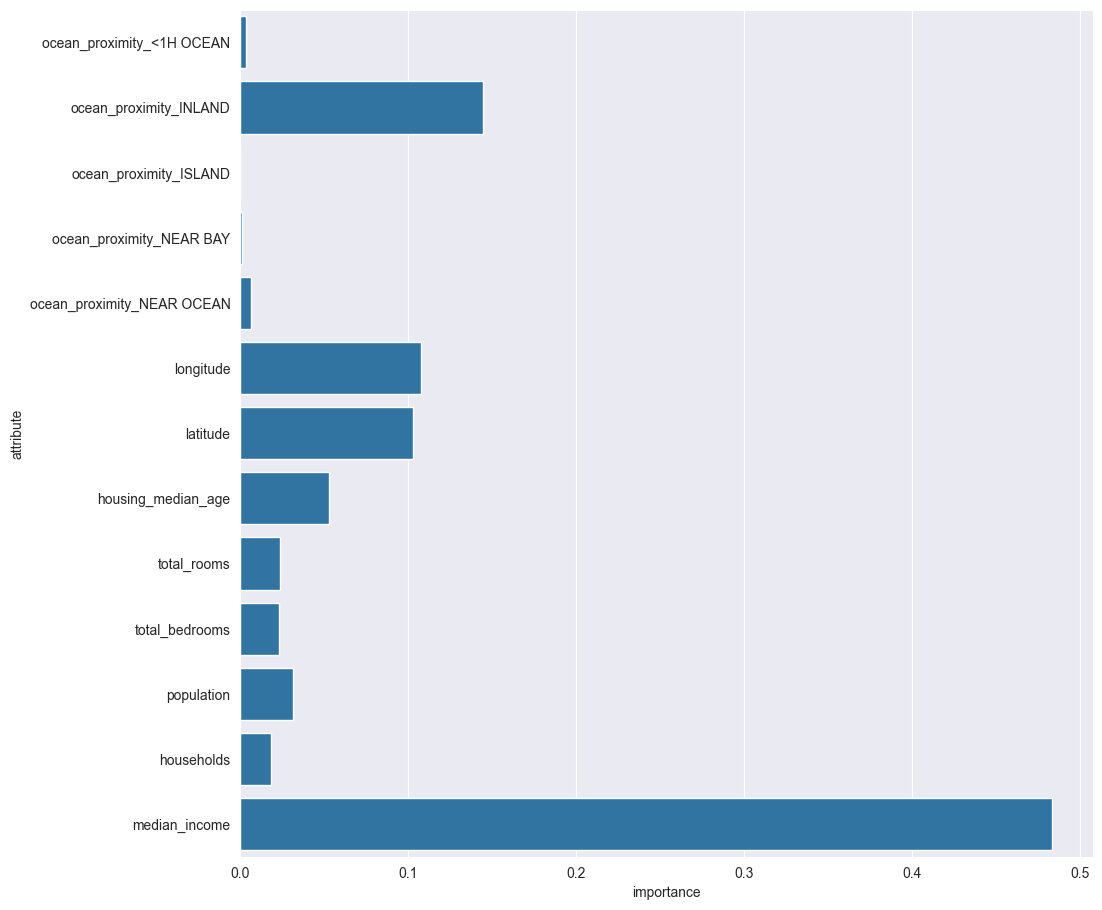

In [29]:
attribute_importance = random_forest_regressor_random_search.best_estimator_.feature_importances_
attributes = column_transformer.get_feature_names_out()

shortened_attributes_names = []

for attribute in attributes:
    shortened_attributes_names.append(attribute[17:])

attribute_importance_dataframe = pandas.DataFrame({
    "attribute":shortened_attributes_names ,
    "importance": attribute_importance
})

plt.figure(figsize=(11,11))
seaborn.barplot(data=attribute_importance_dataframe, x="importance", y="attribute");

We can see that the "median_income" feature have the most impact on our prediction out of all the other attributes. Then comes after it attributes like "ocean_proximity_INLAND", "longitude", and "latitude" which shows that the location and the distance away from the ocean can have a moderate impact on the model results. The rest of the attributes have a very little to no impact on the prediction results.

Here is just a small comparison to demonstrate the difference between the predicted values and actual values.

In [30]:
comparison_dataframe = pandas.DataFrame({
    'actual_median_house_value': test_dataset_targets,
    'predicted_median_house_value': test_dataset_targets_prediction,
    'difference': test_dataset_targets - test_dataset_targets_prediction
})

plotting the comparison data with a scatterplot

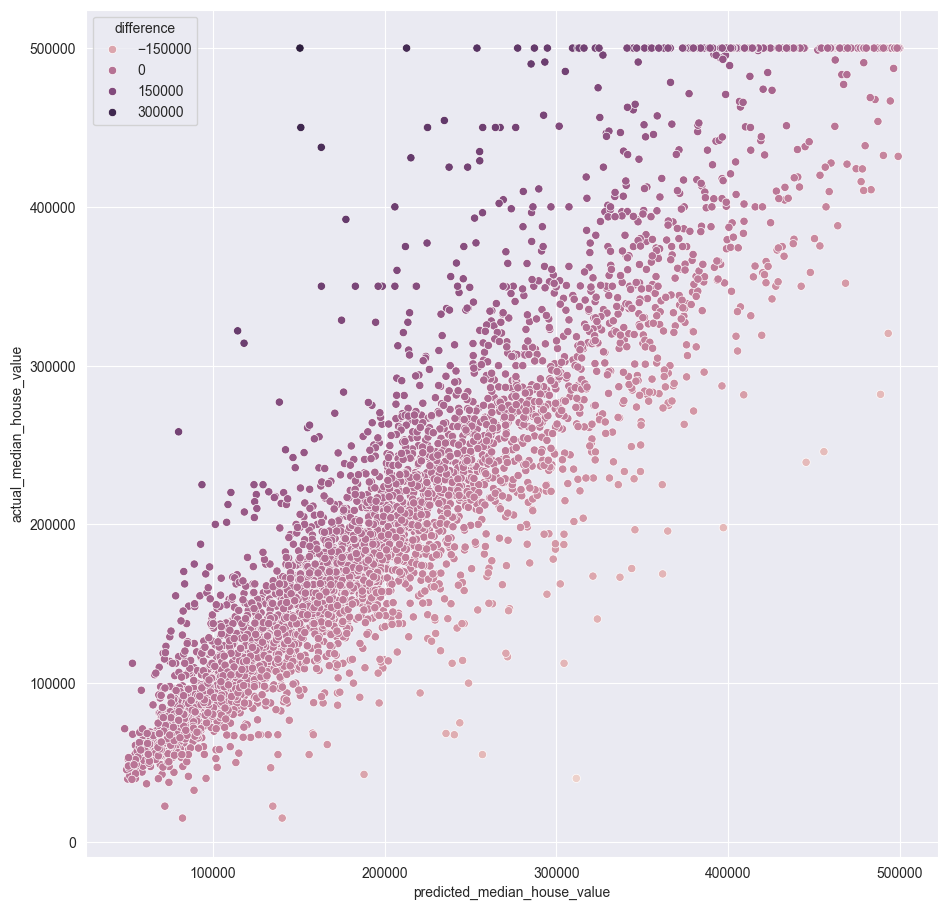

In [31]:
plt.figure(figsize=(11,11))
seaborn.scatterplot(data=comparison_dataframe, x="predicted_median_house_value", y="actual_median_house_value", hue="difference");


We can see that the data distribution is mostly linear with some outliers. The farther away we go from the y=x line, the fewer the data points.

Here is also a histogram of the differences between actual and predicted values:

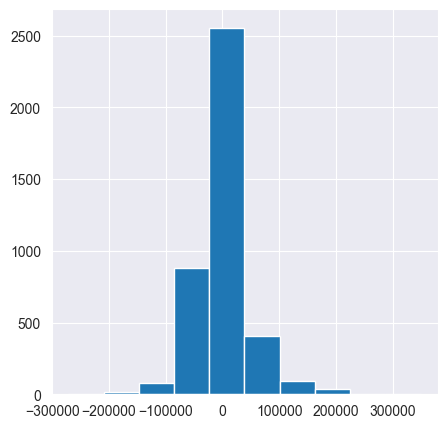

In [32]:
comparison_dataframe["difference"].hist(figsize=(5,5));

Its clear form this histogram that our model can predict the exact house prices most of the time with most of the differences between predicted and actual value being overshot or undershot by less than 100,000

## 8- Discussion And Conclusions

jIn general, the model is now:
- Able to Predict housing prices with very high accuracy.
- Capturing Most of the features that affect housing prices.
- Being highly influenced by the "median_income" feature.

These results give the real estate company a model that they can trust to a great extent when wanting to predict housing prices for their customers.
However, it is still sometimes making predictions that are far off which could be way too high or low for either the buyers or the seller.

In conclusion, the idea of this model can be easily explained to the lead data scientist and deployed to start making accurate prediction on unseen data and solving the companies' initial problem.

## 9- Refrences

- California housing prices (2017). Available at: https://www.kaggle.com/datasets/camnugent/california-housing-prices (Accessed: September 7, 2025).